In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases"
    "/breast-cancer-wisconsin/wdbc.data",
    header=None,
)

In [3]:
print(df.shape)
df.head()

(569, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.iloc[:, 1].unique()

array(['M', 'B'], dtype=object)

In [5]:
from sklearn.preprocessing import LabelEncoder

X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values

le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression())
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
test_acc = pipe.score(X_test, y_test)
print(test_acc)

0.956140350877193


---
### Using k-fold cross-validation to assess model performance

#### Holdout Method:
- 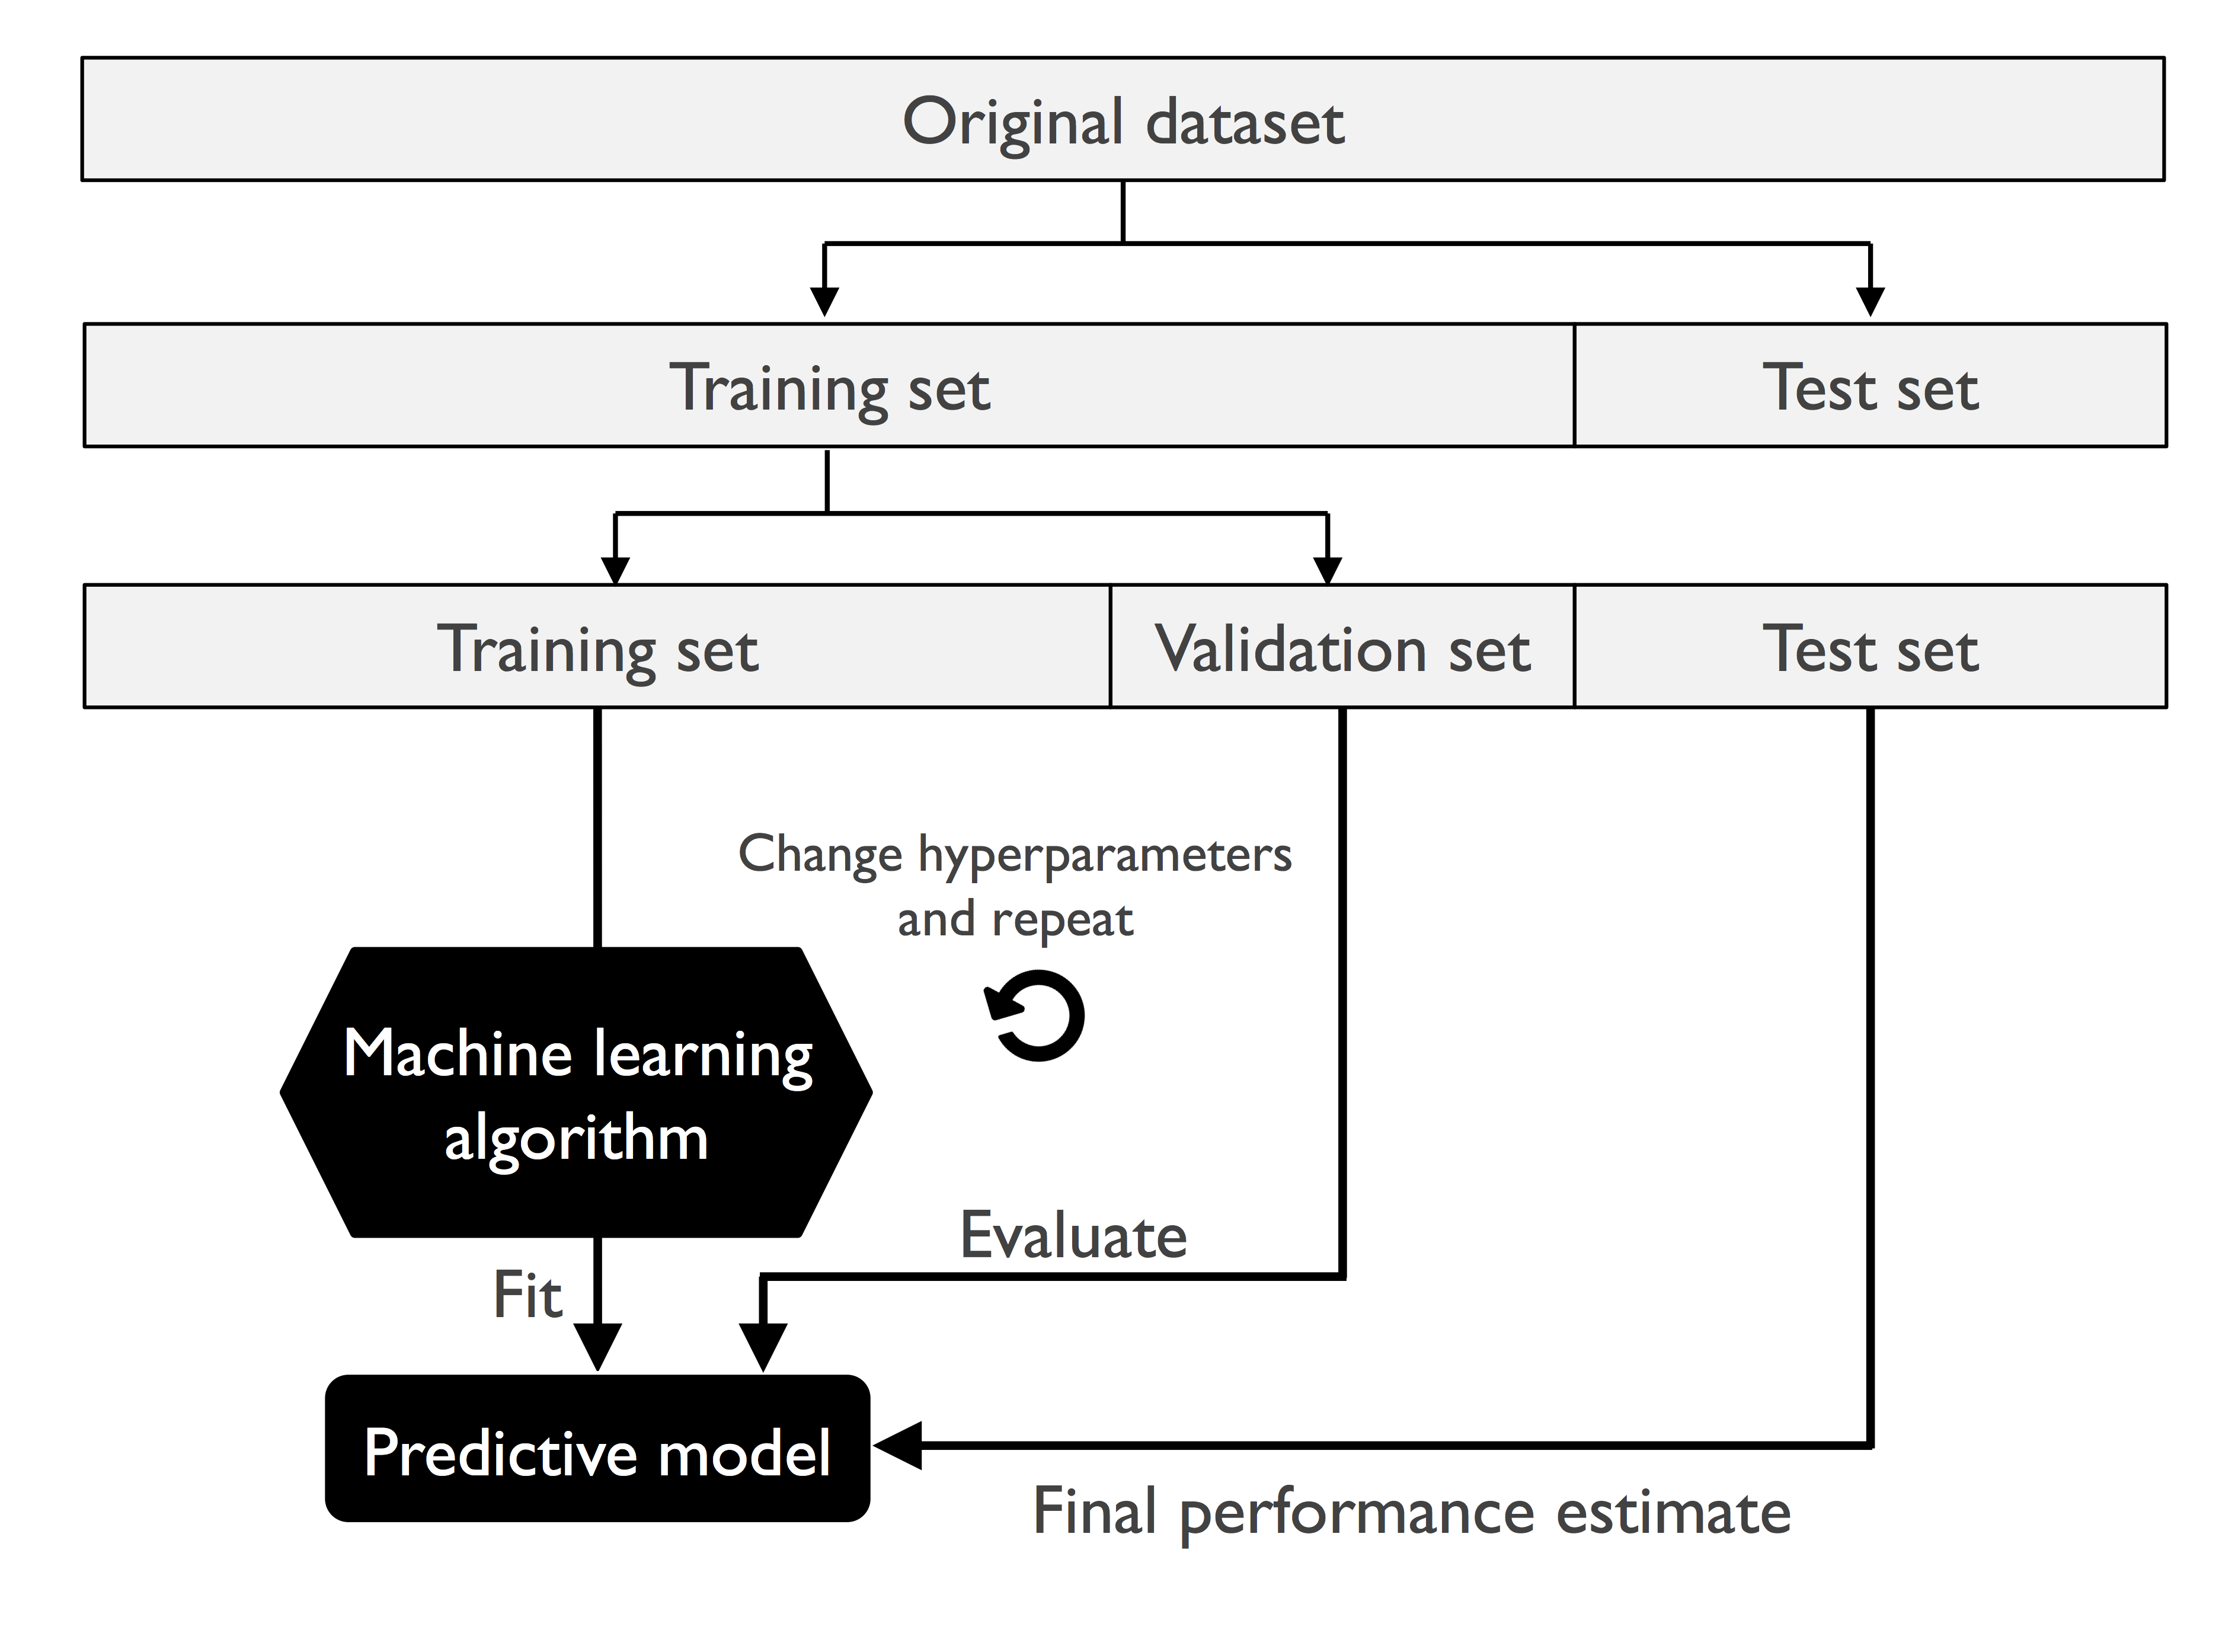

In [8]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []
for k, (train, test) in enumerate(kfold):
    pipe.fit(X_train[train], y_train[train])
    score = pipe.score(X_train[test], y_train[test])
    scores.append(score)

    print(
        f"Fold: {k + 1:02d}, "
        f"Class distr.: {np.bincount(y_train[train])}, "
        f"Acc.: {score:.3f}"
    )

Fold: 01, Class distr.: [256 153], Acc.: 0.935
Fold: 02, Class distr.: [256 153], Acc.: 0.935
Fold: 03, Class distr.: [256 153], Acc.: 0.957
Fold: 04, Class distr.: [256 153], Acc.: 0.957
Fold: 05, Class distr.: [256 153], Acc.: 0.935
Fold: 06, Class distr.: [257 153], Acc.: 0.956
Fold: 07, Class distr.: [257 153], Acc.: 0.978
Fold: 08, Class distr.: [257 153], Acc.: 0.933
Fold: 09, Class distr.: [257 153], Acc.: 0.956
Fold: 10, Class distr.: [257 153], Acc.: 0.956


In [9]:
mean_acc = np.mean(scores)
std_acc = np.std(scores)
print(f"\n CV Accuracy: {mean_acc:.3f} +/- {std_acc: .3f}")


 CV Accuracy: 0.950 +/-  0.014


In [10]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe, X=X_train, y=y_train, cv=10, n_jobs=-1)
print(f"CV Accuracy: {scores}")

CV Accuracy: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]


---
### Debugging algorithms with learning and validation curves

In [11]:
from sklearn.model_selection import learning_curve

pipe = make_pipeline(StandardScaler(), LogisticRegression("l2", max_iter=10000))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=10,
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

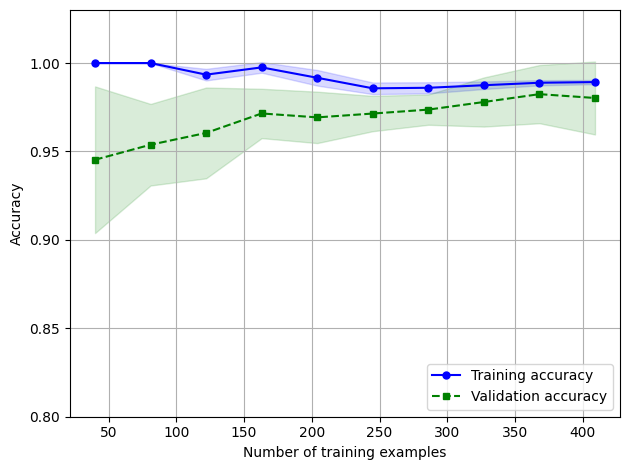

In [12]:
plt.plot(
    train_sizes,
    train_mean,
    color="blue",
    marker="o",
    markersize=5,
    label="Training accuracy",
)

plt.fill_between(
    train_sizes,
    train_mean + train_std,
    train_mean - train_std,
    alpha=0.15,
    color="blue",
)

plt.plot(
    train_sizes,
    test_mean,
    color="green",
    linestyle="--",
    marker="s",
    markersize=5,
    label="Validation accuracy",
)

plt.fill_between(
    train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color="green"
)

plt.grid()
plt.xlabel("Number of training examples")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.ylim([0.8, 1.03])
plt.tight_layout()
# plt.savefig('figures/06_05.png', dpi=300)
plt.show()

### Tuning hyperparameters via `GridSearchCV`

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

param_grid = [
    {"svc__C": param_range, "svc__kernel": ["linear"]},
    {"svc__C": param_range, "svc__gamma": param_range, "svc__kernel": ["rbf"]},
]

gs = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid,
    scoring="accuracy",
    cv=10,
    refit=True,
    n_jobs=-1,
)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9846859903381642
{'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


In [14]:
clf = gs.best_estimator_
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9736842105263158

---
### Exploring hyperparameter configurations more widely with randomized search

---
### Looking at different performance evaluation metrics
##### 1. Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 1 41]]


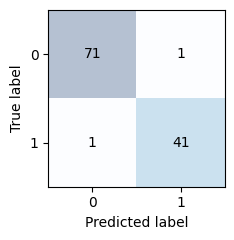

In [ ]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va="center", ha="center")
ax.xaxis.set_ticks_position("bottom")

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

##### 2. ROC-AUC Curve

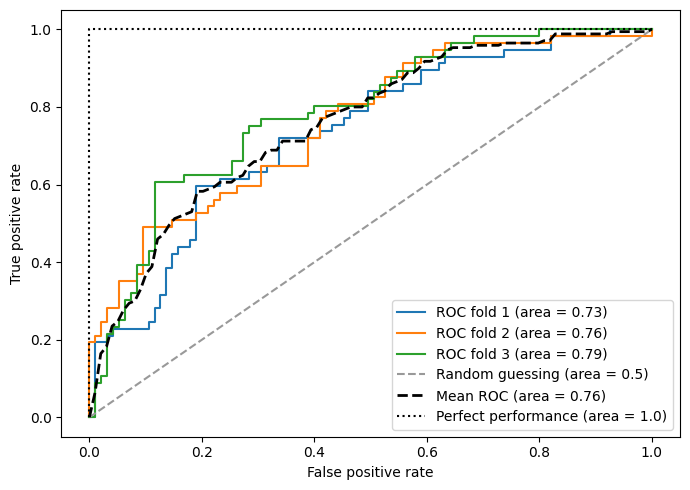

In [ ]:
from sklearn.metrics import roc_curve, auc
from numpy import interp

pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression(penalty="l2", random_state=1, solver="lbfgs", C=100.0),
)
X_train2 = X_train[:, [4, 14]]

cv = list(StratifiedKFold(n_splits=3).split(X_train, y_train))

fig = plt.figure(figsize=(7, 5))

mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(cv):
    probas = pipe.fit(X_train2[train], y_train[train]).predict_proba(X_train2[test])

    fpr, tpr, thresholds = roc_curve(y_train[test], probas[:, 1], pos_label=1)
    mean_tpr += interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC fold {i + 1} (area = {roc_auc:.2f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=(0.6, 0.6, 0.6),
    label="Random guessing (area = 0.5)",
)

mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, "k--", label=f"Mean ROC (area = {mean_auc:.2f})", lw=2)
plt.plot(
    [0, 0, 1],
    [0, 1, 1],
    linestyle=":",
    color="black",
    label="Perfect performance (area = 1.0)",
)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")

plt.tight_layout()
# plt.savefig('figures/06_10.png', dpi=300)
plt.show()

---
### Dealing with class imbalance
- In this section, we will briefly go over some of the techniques that could help with imbalanced data-
sets. But before we discuss different methods to approach this problem, let’s create an imbalanced
dataset from our dataset, which originally consisted of 357 benign tumors (class 0) and 212 malignant
tumors (class 1):

In [ ]:
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

In [ ]:
from sklearn.utils import resample

print("Number of class 1 examples before: ", X_imb[y_imb == 1].shape[0])

X_upsampled, y_upsampled = resample(
    X_imb[y_imb == 1],
    y_imb[y_imb == 1],
    replace=True,
    n_samples=X_imb[y_imb == 0].shape[0],
    random_state=123,
)  # type: ignore
print("Number of class 1 examples after: ", X_upsampled.shape[0])


Number of class 1 examples before:  40
Number of class 1 examples after:  357
